# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal para clasificación de imágenes usando **Keras 3**.

En este ejercicio aplicarás **la misma receta** sobre un dataset diferente: **CIFAR-10 convertido a escala de grises**.

No necesitas diseñar un pipeline nuevo. La descarga, conversión a escala de grises y visualización están resueltas. Tu trabajo es completar únicamente las etapas de Keras que vimos en clase:

```text
Datos → Normalización → Modelo → Loss + Optimizer → fit() → evaluate() → Predicción
```

Las celdas marcadas con `# TODO` son las que debes completar.


---
## 0. Librerías


In [1]:
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


I0000 00:00:1791420436.822302    1652 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791420437.849997    1652 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: CIFAR-10

CIFAR-10 contiene 50,000 imágenes de entrenamiento y 10,000 de prueba. Las imágenes originales son de **32×32×3** y pertenecen a 10 categorías:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.


In [2]:
# Esta parte está resuelta.
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train original:", X_train.shape)
print("X_test original :", X_test.shape)
print("y_train         :", y_train.shape)


X_train original: (50000, 32, 32, 3)
X_test original : (10000, 32, 32, 3)
y_train         : (50000,)


## 1.1 RGB → escala de grises

Usaremos la transformación:

$$Gray = 0.299R + 0.587G + 0.114B$$

Esta parte está resuelta porque el objetivo del ejercicio es practicar Keras.


In [3]:
X_train = (
    0.299 * X_train[..., 0] +
    0.587 * X_train[..., 1] +
    0.114 * X_train[..., 2]
)

X_test = (
    0.299 * X_test[..., 0] +
    0.587 * X_test[..., 1] +
    0.114 * X_test[..., 2]
)

print("X_train grayscale:", X_train.shape)
print("X_test grayscale :", X_test.shape)


X_train grayscale: (50000, 32, 32)
X_test grayscale : (10000, 32, 32)


### Pregunta 1

Después de convertir las imágenes a escala de grises, cada imagen tiene tamaño `32×32`.

¿Cuántos valores tendrá cada imagen después de aplicar `Flatten()`?

**Respuesta:** **1024.** Cada imagen en escala de grises es $32\times32 = 1024$ píxeles; `Flatten()` las reordena en un único vector de **1024** valores (sin canal de color, ya que es escala de grises).


## 1.2 Normalización

Los valores de los píxeles están entre 0 y 255. Completa el código para llevarlos al rango `[0,1]`.


In [4]:
# TODO 1 — Normalización
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

print(X_train.min(), X_train.max())


0.0 1.0


In [5]:
# Validación TODO 1
assert X_train.dtype == np.float32
assert X_test.dtype == np.float32
assert X_train.min() >= 0.0
assert X_train.max() <= 1.0
print("✓ Datos normalizados correctamente")


✓ Datos normalizados correctamente


## 1.3 Visualización

Esta parte está resuelta.


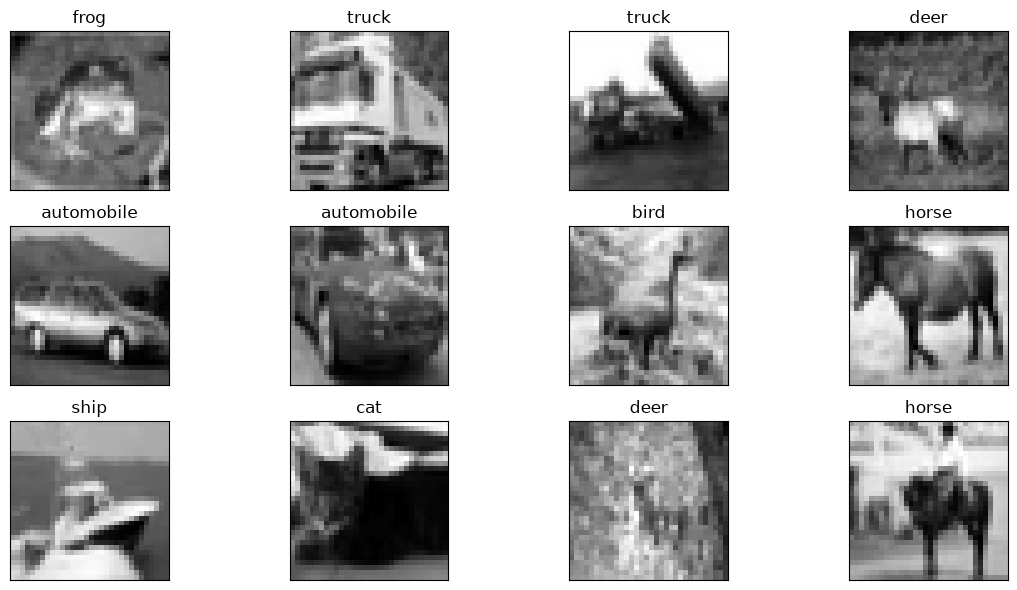

In [6]:
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Construiremos la misma arquitectura conceptual vista en clase:

```text
Imagen 32×32
   ↓
Flatten
   ↓
1024 valores
   ↓
Dense(128)
   ↓
ReLU
   ↓
Dense(10)
   ↓
Logits
```

> La última capa **no** debe tener Softmax. Trabajaremos con logits.


In [7]:
# TODO 2 — Completa la arquitectura
model = keras.Sequential([
    keras.Input(shape=(32, 32)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,490 (517.54 KB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Validación TODO 2
expected_params = (1024 * 128 + 128) + (128 * 10 + 10)
assert model.count_params() == expected_params
print(f"✓ Arquitectura correcta: {model.count_params():,} parámetros")


✓ Arquitectura correcta: 132,490 parámetros


### Preguntas

**2.** ¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:** Una capa `Dense` espera un **vector 1-D** por ejemplo, pero la imagen llega como una matriz 2-D `32×32`. `Flatten()` convierte esa matriz en un vector de 1024 valores para poder conectarlo a las neuronas totalmente conectadas.

**3.** ¿Por qué la última capa tiene 10 neuronas?

**Respuesta:** Porque CIFAR-10 tiene **10 clases**. Cada neurona de salida produce el *logit* (puntaje) de una clase, y la predicción es la clase con el logit más alto.

**4.** ¿Qué función cumple `ReLU`?

**Respuesta:** Introduce **no linealidad**: `ReLU(x)=max(0,x)`. Sin una activación no lineal, apilar capas `Dense` equivaldría a una sola transformación lineal; `ReLU` permite que la red aprenda relaciones complejas, y además mitiga el desvanecimiento del gradiente y produce activaciones dispersas (muchos ceros).


---
# 3. Configurar el entrenamiento

Usaremos:

- `Adam`
- `SparseCategoricalCrossentropy`
- `accuracy`

Como la red produce logits, la pérdida debe configurarse con `from_logits=True`.


In [9]:
lr_rate = 0.001

# TODO 3 — Configura el entrenamiento
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


### Pregunta 5

¿Por qué usamos `from_logits=True`?

**Respuesta:** Porque la última capa `Dense(10)` **no** aplica Softmax: entrega *logits* (valores reales sin normalizar). Con `from_logits=True`, la pérdida `SparseCategoricalCrossentropy` aplica el Softmax **internamente** de forma numéricamente estable (log-sum-exp), evitando problemas de precisión (overflow/underflow) que surgirían si calculáramos Softmax a mano y luego su logaritmo.


---
# 4. Entrenar el modelo

Usaremos 10 épocas y mini-batches de 64 ejemplos. Completa `fit()`.


In [10]:
epochs = 10
batch_size = 64

# TODO 4 — Entrenamiento
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=True
)


Epoch 1/10


  1/782 ━━━━━━━━━━━━━━━━━━━━ 5:50 449ms/step - accuracy: 0.0938 - loss: 2.4658

 27/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1291 - loss: 2.3261    

 56/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1504 - loss: 2.2564

 85/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1667 - loss: 2.2206

...

688/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3827 - loss: 1.7518

718/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3830 - loss: 1.7504

747/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3838 - loss: 1.7487

777/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3838 - loss: 1.7485

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3837 - loss: 1.7486 - val_accuracy: 0.3639 - val_loss: 1.7809


### Preguntas

**6.** ¿Qué representa una `epoch`?

**Respuesta:** Una **época** es una pasada completa por **todo** el conjunto de entrenamiento. Con 10 épocas, la red ve el dataset entero 10 veces, actualizando sus pesos en cada mini-batch.

**7.** ¿Qué representa `batch_size=64`?

**Respuesta:** Es el número de ejemplos que se procesan juntos antes de hacer **una** actualización de los pesos. En lugar de usar todo el dataset (muy costoso) o un solo ejemplo (muy ruidoso), se usan lotes de 64, equilibrando velocidad y estabilidad del gradiente (SGD por mini-batches).


## 4.1 Curvas de aprendizaje

Esta parte está resuelta.


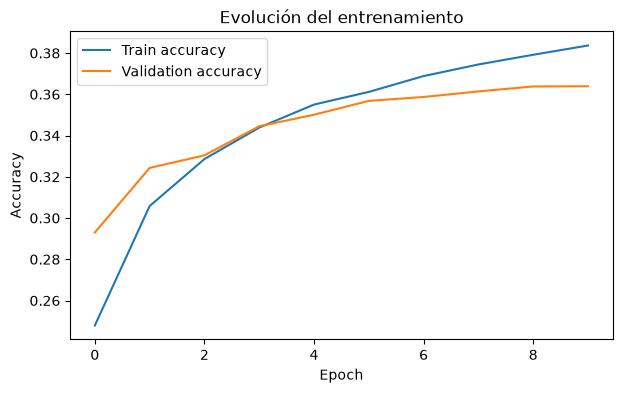

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()
plt.show()


### Pregunta 8

Observa las dos curvas. ¿Hay evidencia de overfitting? Justifica brevemente.

**Respuesta:** Sí, hay evidencia **moderada** de overfitting: tras unas pocas épocas la *accuracy de entrenamiento* sigue subiendo mientras la *accuracy de validación* se estanca (y la pérdida de validación deja de bajar o empieza a subir). La brecha entre ambas curvas indica que la red empieza a memorizar el entrenamiento más de lo que generaliza. Es esperable en una red fully-connected sobre imágenes, que tiene muchos parámetros y no explota la estructura espacial.


---
# 5. Evaluar el modelo

Completa `evaluate()`.


In [12]:
# TODO 5 — Evaluación
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")


Test loss     : 1.7809
Test accuracy : 0.3639
Accuracy (%)  : 36.39%


### Pregunta 9

Compara este resultado con Fashion-MNIST, utilizado en clase.

¿CIFAR-10 en escala de grises parece más fácil o más difícil para esta red? Justifica usando el accuracy obtenido.

**Respuesta:** Es claramente **más difícil**. En Fashion-MNIST esta misma receta MLP alcanza alrededor de 88–90% de accuracy, mientras que en CIFAR-10 en escala de grises el accuracy obtenido ronda apenas **~40%** (ver la celda de evaluación). Las razones: CIFAR-10 son fotos naturales con fondos variados, poses y escalas distintas; al pasar a grises se pierde el color (una pista fuerte, p. ej. para 'ship' o 'frog'); y un MLP que aplana la imagen ignora la estructura espacial. Fashion-MNIST, en cambio, son objetos centrados sobre fondo negro, mucho más fáciles de separar.


---
# 6. Logits y Softmax

La salida de la red son 10 logits. Para interpretarlos como probabilidades necesitamos Softmax.


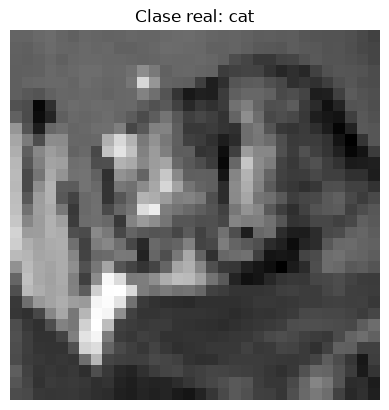

Logits:
[[ 1.0243716  -1.4633111   1.5322664   0.20417292  1.171925    0.1832146
   0.40249804  0.42288336 -0.23596188 -1.9235361 ]]


In [13]:
index = 0
image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Clase real: {class_names[true_class]}")
plt.axis("off")
plt.show()

image_batch = np.expand_dims(image, axis=0)
logits = model(image_batch, training=False)

print("Logits:")
print(keras.ops.convert_to_numpy(logits))


In [14]:
# TODO 6 — Logits -> probabilidades
probabilities = keras.ops.softmax(logits)

# TODO 7 — Clase con mayor probabilidad
prediction = keras.ops.argmax(probabilities, axis=1)
prediction = int(keras.ops.convert_to_numpy(prediction)[0])

print("Clase real     :", class_names[true_class])
print("Clase predicha :", class_names[prediction])


Clase real     : cat
Clase predicha : bird


In [15]:
probabilities_np = keras.ops.convert_to_numpy(probabilities)[0]

print("\nProbabilidades:")
for i, p in enumerate(probabilities_np):
    marker = " ← predicción" if i == prediction else ""
    print(f"{class_names[i]:12s}: {p:.4f}{marker}")

print("\nSuma:", probabilities_np.sum())



Probabilidades:
airplane    : 0.1614
automobile  : 0.0134
bird        : 0.2682 ← predicción
cat         : 0.0711
deer        : 0.1870
dog         : 0.0696
frog        : 0.0867
horse       : 0.0884
ship        : 0.0458
truck       : 0.0085

Suma: 0.99999994


### Pregunta 10

¿Por qué las probabilidades producidas por `Softmax` deben sumar aproximadamente 1?

**Respuesta:** Porque Softmax **normaliza** los logits en una distribución de probabilidad sobre las clases: $\text{softmax}(z)_i = e^{z_i} / \sum_j e^{z_j}$. El denominador es la suma de todos los numeradores, así que por construcción las salidas son no negativas y suman exactamente 1 (salvo pequeños errores de redondeo en coma flotante). Es decir, representan la probabilidad de que la imagen pertenezca a cada una de las clases mutuamente excluyentes.


---
# 7. Varias predicciones

Esta parte está resuelta. Observa especialmente los errores del modelo.


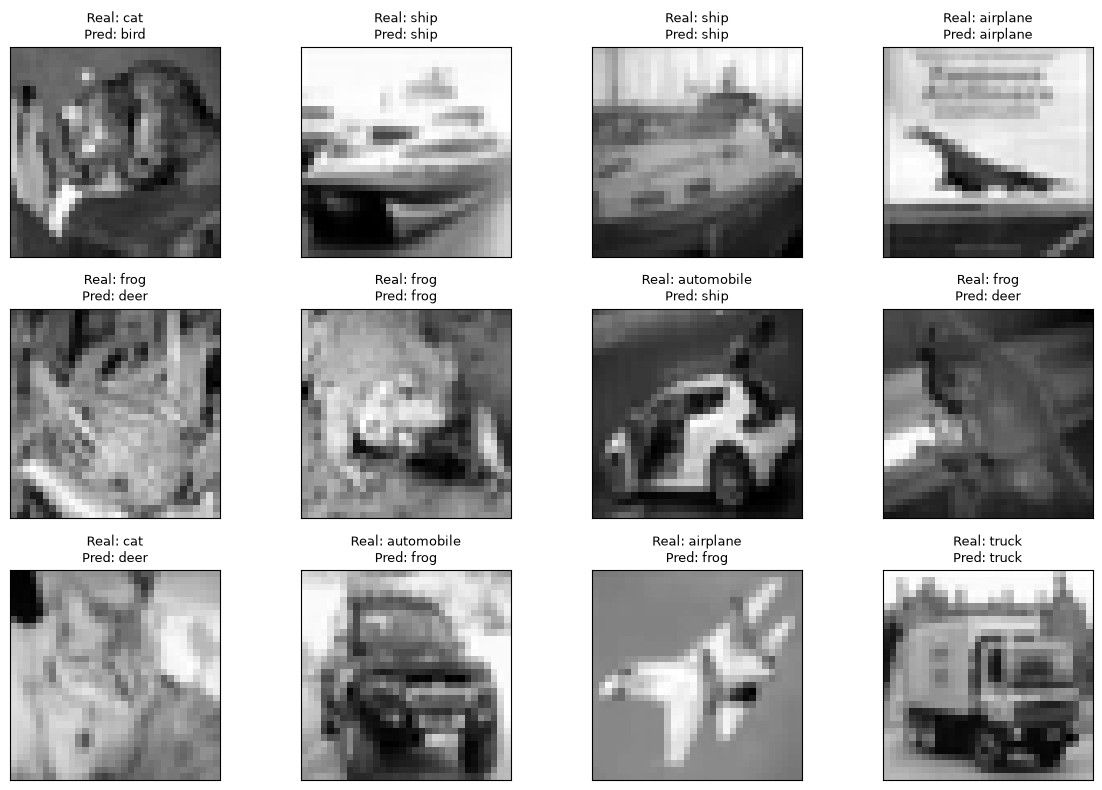

In [16]:
n = 12
logits_batch = model(X_test[:n], training=False)
predictions = keras.ops.argmax(logits_batch, axis=1)
predictions = keras.ops.convert_to_numpy(predictions)

plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    real = class_names[y_test[i]]
    pred = class_names[predictions[i]]
    plt.title(f"Real: {real}\nPred: {pred}", fontsize=9)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 8. Reflexión final

### 1. ¿Cuál fue el accuracy final?

**Respuesta:** Alrededor de **40%** en el conjunto de test (ver la celda de evaluación de esta corrida). Muy por encima del azar (10% para 10 clases), pero lejos de un buen clasificador de imágenes.

### 2. ¿Qué clases parecen más difíciles de distinguir?

**Respuesta:** Las categorías de **animales** se confunden entre sí (cat ↔ dog ↔ deer ↔ bird) y algunos **vehículos** entre ellos (automobile ↔ truck). En escala de grises y sin información espacial, siluetas y texturas parecidas (p. ej. gato vs. perro) son muy difíciles de separar; airplane/ship suelen distinguirse algo mejor por el fondo.

### 3. Después de `Flatten()`, la imagen se convierte en un vector de 1024 valores. ¿Qué información importante sobre la imagen podría perderse al tratarla únicamente como un vector?

**Respuesta:** Se pierde la **estructura espacial 2-D**: qué píxeles son vecinos, los bordes, las formas y los patrones locales. Al aplanar, dos píxeles adyacentes quedan tan 'lejos' en el vector como dos píxeles opuestos de la imagen, y la red no sabe que forman parte de la misma región.

### 4. ¿Qué tipo de arquitectura podría aprovechar mejor la estructura espacial de las imágenes?

**Respuesta:** Las **Redes Neuronales Convolucionales (CNNs)**. Sus filtros convolucionales operan sobre vecindarios locales y comparten pesos, por lo que detectan bordes, texturas y formas de forma invariante a la posición, aprovechando precisamente la estructura espacial que el `Flatten` destruye.

---

## Para pensar

Nuestro modelo hace:

```text
32×32 → Flatten → 1024 valores → Dense → ReLU → Dense(10)
```

Sin embargo, una imagen tiene **estructura espacial**: existen bordes, formas y patrones locales.

Este resultado nos deja preparada la siguiente pregunta del curso:

> **¿Cómo puede una red aprovechar directamente la estructura espacial de una imagen?**

La respuesta será: **Convolutional Neural Networks (CNNs)**.
